In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(158).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(94).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(147).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(99).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(59).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(171).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(71).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(138).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(111).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(197).JPG
/kaggle/input/datasets/olyadgetch/wheat-leaf-dataset/wheat_leaf/stripe_rust/lolr(88).JPG
/kaggle/input/d

In [ ]:
print("Hi")

In [5]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ── Check GPU ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [14]:

CONFIG = {
    "data_dir"       : "/kaggle/input/datasets/jayaprakashpondy/wheat-leaf-disease/Dataset",
    "img_size"       : 224,
    "batch_size"     : 16,
    "num_epochs"     : 30,
    "lr"             : 1e-3,      # head-only phase
    "weight_decay"   : 1e-4,
    "unfreeze_epoch" : 10,        # epoch to start fine-tuning the backbone
    "fine_tune_lr"   : 1e-5,      # backbone LR after unfreezing
    "num_classes"    : 5,
    "seed"           : 42,
    "save_dir"       : "/kaggle/working/checkpoints/",
}

CLASSES = ["Brown rust", "Healthy", "Loose Smut","Septoria", "Yellow rust"]

os.makedirs(CONFIG["save_dir"], exist_ok=True)
print("Config ready ")

Config ready 


In [15]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
print(f"Seed set to {CONFIG['seed']} ")

Seed set to 42 


In [16]:
# ── Check folder structure ──
data_dir = CONFIG["data_dir"]

print("Dataset structure:")
for folder in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"  {folder}/  →  {count} images")

Dataset structure:
  Brown rust/  →  1256 images
  Healthy/  →  1658 images
  Loose Smut/  →  939 images
  Septoria/  →  349 images
  Yellow rust/  →  1395 images


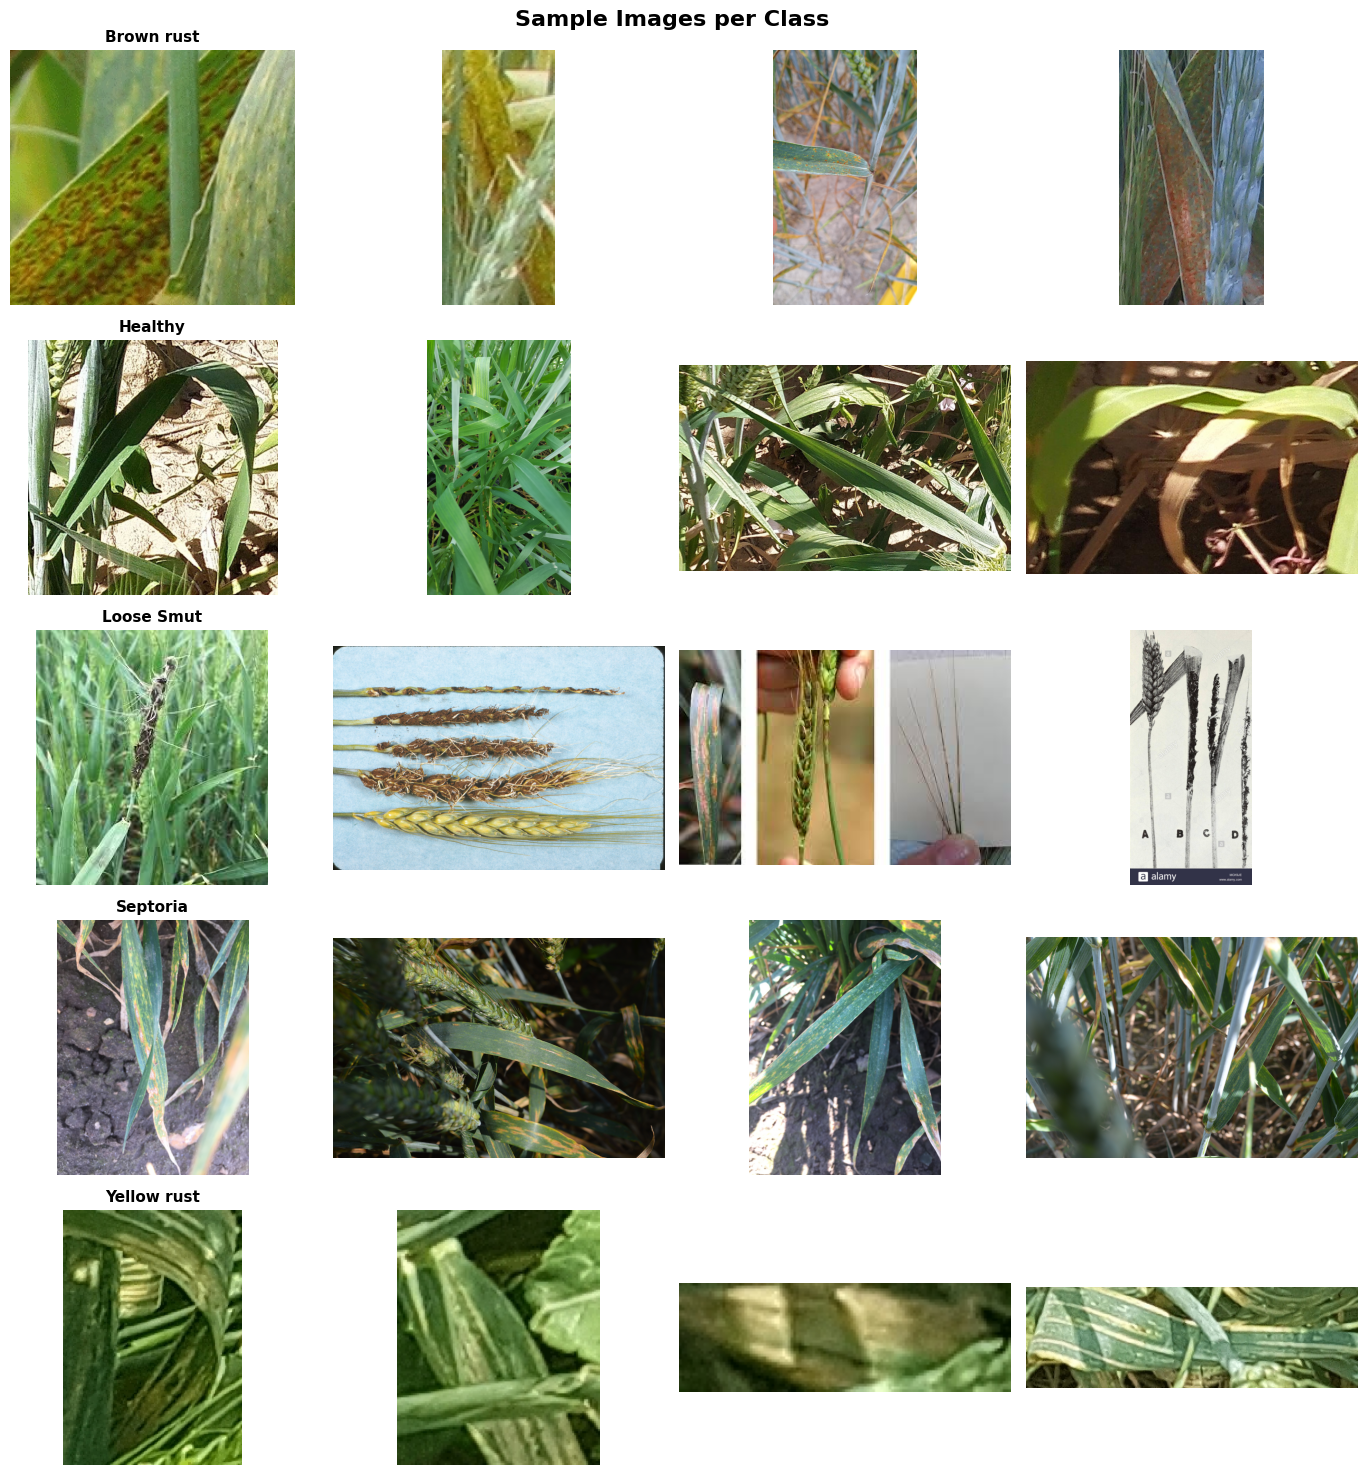

In [18]:
# ── Visualize sample images ──
classes = [d for d in sorted(os.listdir(data_dir)) 
           if os.path.isdir(os.path.join(data_dir, d))]

fig, axes = plt.subplots(len(classes), 4, figsize=(14, 3 * len(classes)))
fig.suptitle("Sample Images per Class", fontsize=16, fontweight="bold")

for row, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    if not os.path.isdir(cls_path):
        continue
    imgs = os.listdir(cls_path)[:4]
    for col, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls if col == 0 else "", fontsize=11, fontweight="bold")
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/sample_images.png", dpi=150)
plt.show()

In [19]:
def get_transforms(img_size, split):
    """
    Training: aggressive augmentation (small dataset → high overfitting risk)
    Val/Test: only resize + normalize
    """
    mean = [0.485, 0.456, 0.406]  # ImageNet stats
    std  = [0.229, 0.224, 0.225]

    if split == "train":
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
            transforms.RandomErasing(p=0.1),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


def get_dataloaders(config):
    img_size   = config["img_size"]
    batch_size = config["batch_size"]
    seed       = config["seed"]
    data_dir   = config["data_dir"]

    # Load dataset (no transform yet — we apply per-split below)
    full_ds = datasets.ImageFolder(root=data_dir)
    n       = len(full_ds)
    indices = list(range(n))
    targets = full_ds.targets

    print(f"Total images : {n}")
    print(f"Classes      : {full_ds.classes}")
    for cls, cnt in zip(full_ds.classes, np.bincount(targets)):
        print(f"  {cls}: {cnt}")

    # Stratified 70 / 15 / 15 split
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.30, stratify=targets, random_state=seed
    )
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.50,
        stratify=[targets[i] for i in temp_idx],
        random_state=seed,
    )
    print(f"\nSplits — Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

    # Build per-split subsets with correct transforms
    def make_subset(idx, split):
        ds = datasets.ImageFolder(root=data_dir, transform=get_transforms(img_size, split))
        return Subset(ds, idx)

    train_ds = make_subset(train_idx, "train")
    val_ds   = make_subset(val_idx,   "val")
    test_ds  = make_subset(test_idx,  "test")

    # Weighted sampler — oversample minority classes
    train_labels   = [targets[i] for i in train_idx]
    class_counts   = np.bincount(train_labels, minlength=len(full_ds.classes))
    sample_weights = [1.0 / class_counts[l] for l in train_labels]
    sampler        = WeightedRandomSampler(sample_weights, len(train_idx), replacement=True)

    # Class weights for loss function
    cw = 1.0 / (class_counts + 1e-6)
    class_weights = torch.tensor(cw / cw.sum() * len(full_ds.classes), dtype=torch.float32)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,    num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,    num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader, class_weights


train_loader, val_loader, test_loader, class_weights = get_dataloaders(CONFIG)
print(f"\nClass weights: {class_weights}")

Total images : 5521
Classes      : ['Brown rust', 'Healthy', 'Loose Smut', 'Septoria', 'Yellow rust']
  Brown rust: 1256
  Healthy: 1591
  Loose Smut: 930
  Septoria: 349
  Yellow rust: 1395

Splits — Train: 3864 | Val: 828 | Test: 829

Class weights: tensor([0.6542, 0.5162, 0.8834, 2.3569, 0.5892])


In [20]:
def build_model(num_classes, freeze_backbone=True):
    """
    EfficientNet-B0 pretrained on ImageNet.
    We replace the final classifier with a custom head.
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes),
    )
    return model


model = build_model(CONFIG["num_classes"], freeze_backbone=True).to(device)

# Count parameters
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  (backbone frozen)")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


Total params    : 4,336,769
Trainable params: 329,221  (backbone frozen)


In [21]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc="  Eval ", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        preds   = outputs.argmax(1)

        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


print("Training functions defined ")

Training functions defined 


In [22]:
# ── Loss, Optimizer, Scheduler ──
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"])

history    = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

print("Ready to train!")

Ready to train!


In [23]:
print("=" * 60)
print(" Wheat Leaf Disease Classifier — Training")
print("=" * 60)

for epoch in range(1, CONFIG["num_epochs"] + 1):

    # ── Phase 2: Unfreeze backbone ──
    if epoch == CONFIG["unfreeze_epoch"]:
        print("\n🔓 Unfreezing backbone — starting fine-tuning...")
        for param in model.parameters():
            param.requires_grad = True
        # Add backbone params with lower LR
        optimizer.add_param_group({
            "params": model.features.parameters(),
            "lr": CONFIG["fine_tune_lr"]
        })
        scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"] - epoch)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"   Trainable params: {trainable:,}\n")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    status = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {"epoch": epoch, "val_acc": val_acc, "model_state": model.state_dict()},
            os.path.join(CONFIG["save_dir"], "best_model.pth")
        )
        status = " ✅ Best saved"

    print(
        f"Epoch [{epoch:02d}/{CONFIG['num_epochs']}] "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}{status}"
    )

print(f"\nTraining complete! Best Val Acc: {best_val_acc:.4f}")

 Wheat Leaf Disease Classifier — Training


  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

Epoch [01/30] Train Loss: 0.6568  Acc: 0.7156 | Val Loss: 0.4627  Acc: 0.8116 ✅ Best saved


  Train:   0%|          | 0/242 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

Epoch [29/30] Train Loss: 0.1603  Acc: 0.9242 | Val Loss: 0.1098  Acc: 0.9662 ✅ Best saved


  Train:   0%|          | 0/242 [00:00<?, ?it/s]

  Eval :   0%|          | 0/52 [00:00<?, ?it/s]

Epoch [30/30] Train Loss: 0.1617  Acc: 0.9211 | Val Loss: 0.1108  Acc: 0.9626

Training complete! Best Val Acc: 0.9662


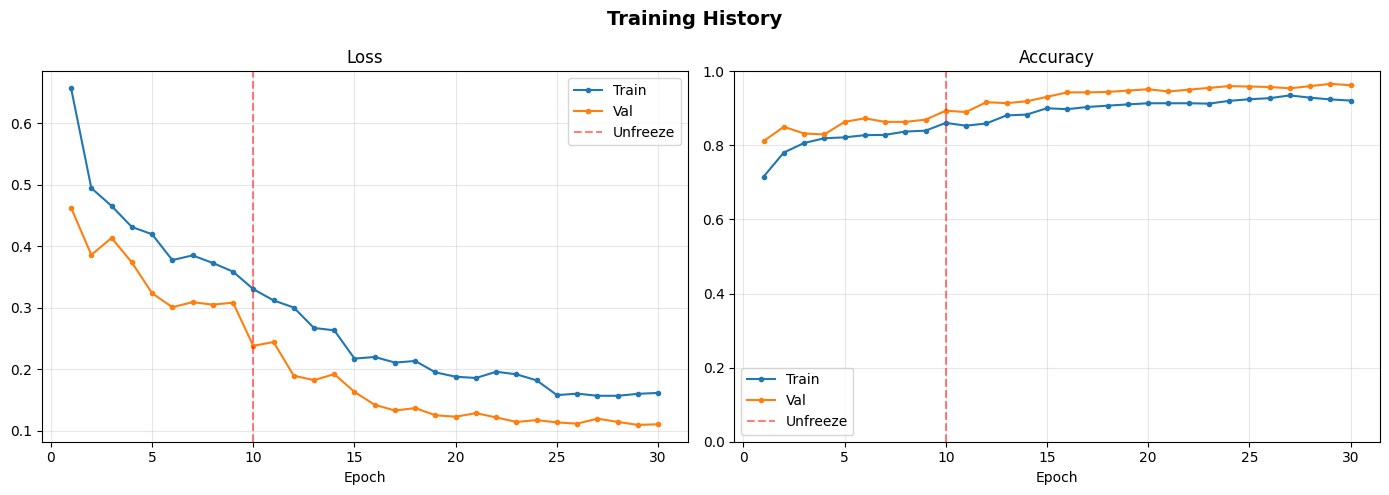

In [24]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

axes[0].plot(epochs, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(epochs, history["val_loss"],   label="Val",   marker="o", markersize=3)
axes[0].axvline(CONFIG["unfreeze_epoch"], color="red", linestyle="--", alpha=0.5, label="Unfreeze")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(epochs, history["val_acc"],   label="Val",   marker="o", markersize=3)
axes[1].axvline(CONFIG["unfreeze_epoch"], color="red", linestyle="--", alpha=0.5, label="Unfreeze")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

In [25]:
# Load best model
ckpt = torch.load(os.path.join(CONFIG["save_dir"], "best_model.pth"), map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch']} (val_acc={ckpt['val_acc']:.4f})")

test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}\n")
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Loaded best model from epoch 29 (val_acc=0.9662)


  Eval :   0%|          | 0/52 [00:00<?, ?it/s]


Test Accuracy : 0.9566
Test Loss     : 0.1100

              precision    recall  f1-score   support

  Brown rust     0.9735    0.9735    0.9735       189
     Healthy     0.9914    0.9665    0.9788       239
  Loose Smut     1.0000    0.9928    0.9964       139
    Septoria     0.7183    0.9808    0.8293        52
 Yellow rust     0.9545    0.9000    0.9265       210

    accuracy                         0.9566       829
   macro avg     0.9276    0.9627    0.9409       829
weighted avg     0.9623    0.9566    0.9579       829



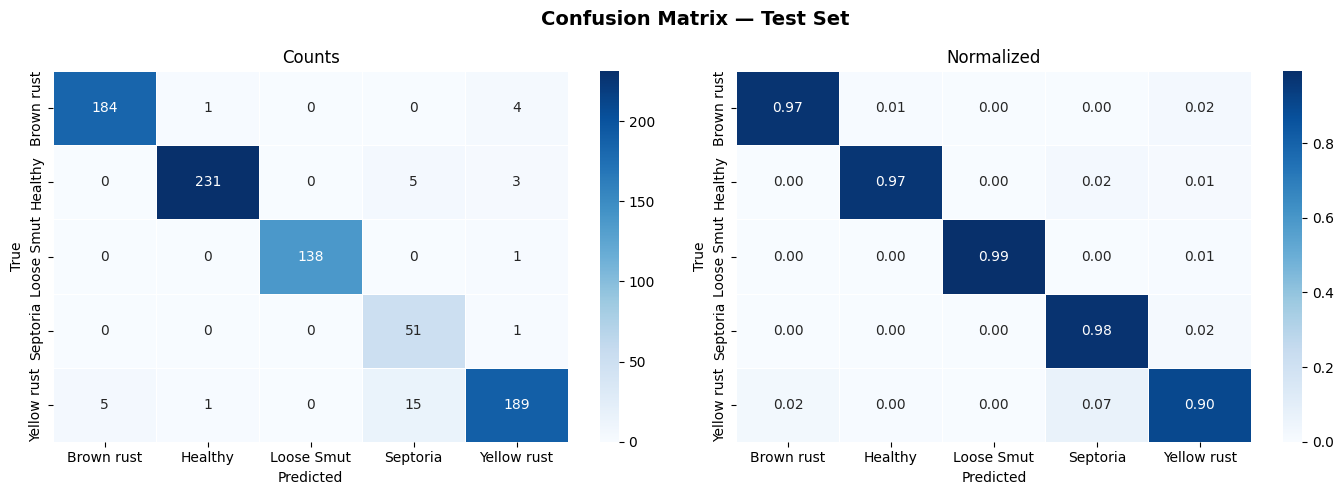

In [26]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")

for ax, data, fmt, title in zip(
    axes, [cm, cm_norm], ["d", ".2f"], ["Counts", "Normalized"]
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
plt.show()

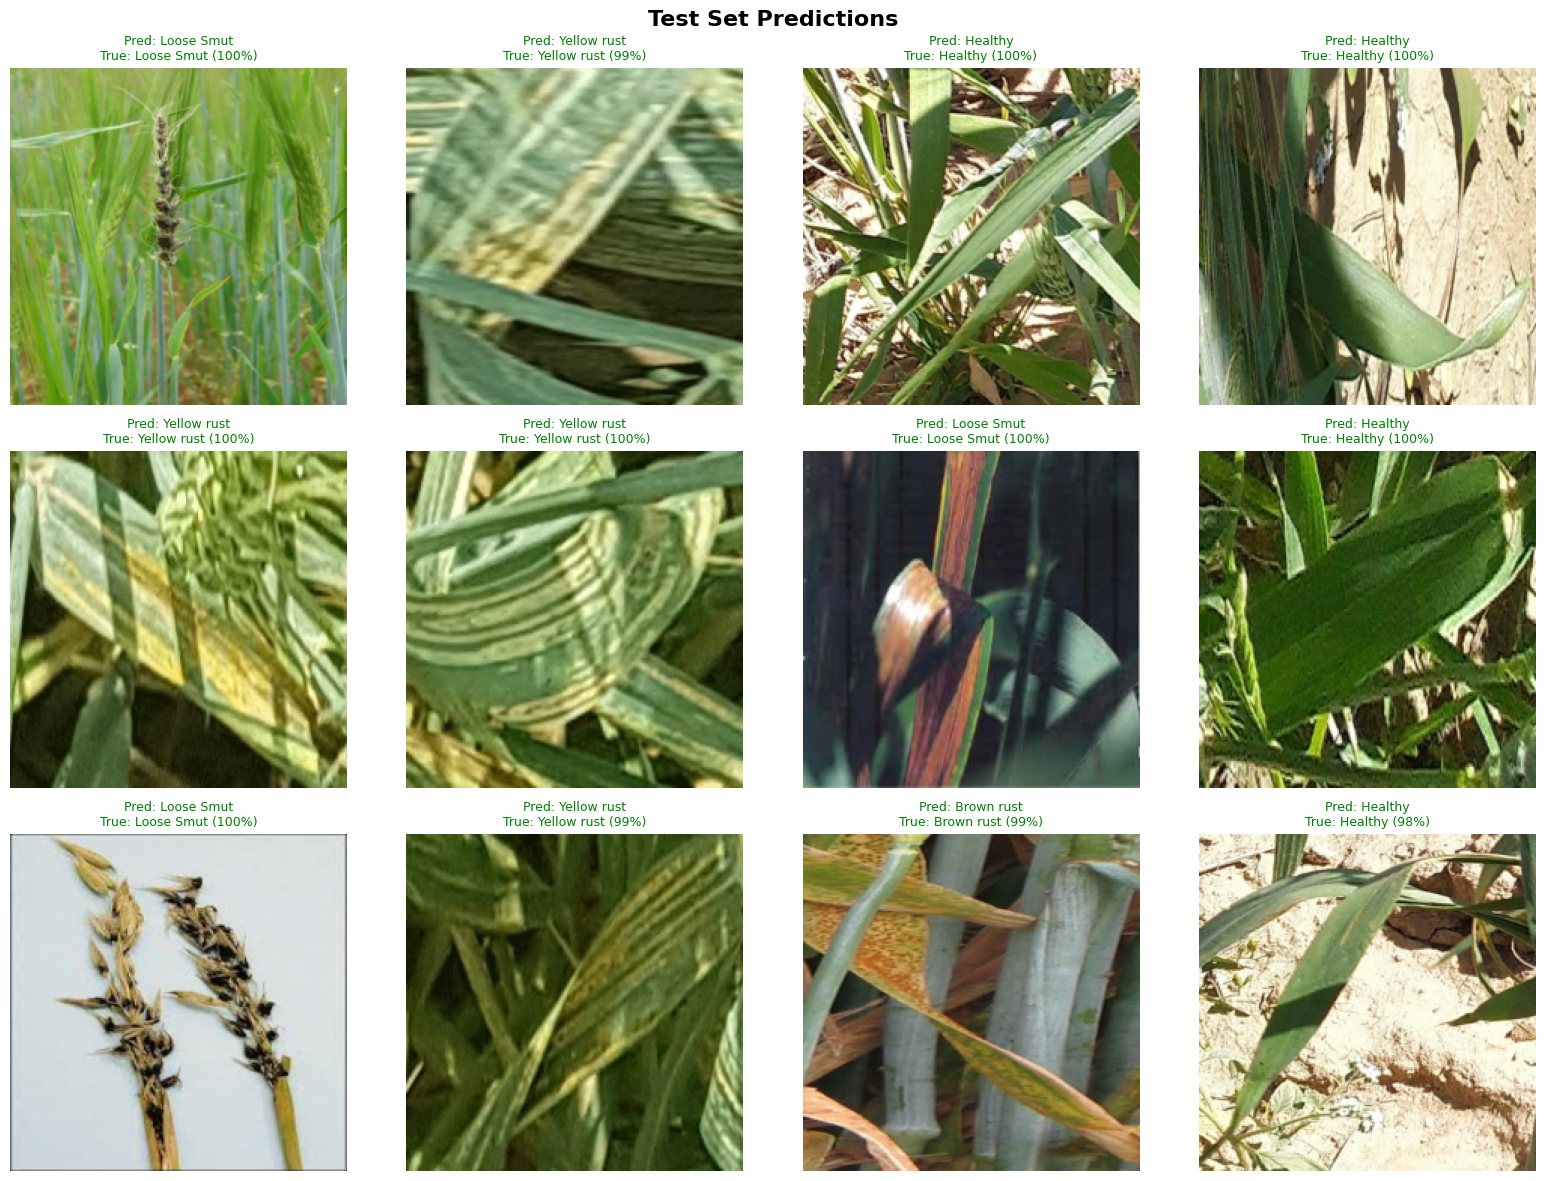

In [27]:
@torch.no_grad()
def visualize_predictions(model, loader, classes, n=12):
    model.eval()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    imgs_shown, preds_all, labels_all, probs_all = [], [], [], []

    for imgs, labels in loader:
        out   = model(imgs.to(device))
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        imgs_shown.extend(imgs.numpy())
        preds_all.extend(preds)
        labels_all.extend(labels.numpy())
        probs_all.extend(probs)
        if len(imgs_shown) >= n:
            break

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle("Test Set Predictions", fontsize=16, fontweight="bold")

    for i, ax in enumerate(axes.flatten()):
        if i >= n:
            ax.axis("off")
            continue
        img = imgs_shown[i].transpose(1, 2, 0) * std + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        pred  = classes[preds_all[i]]
        true  = classes[labels_all[i]]
        conf  = probs_all[i][preds_all[i]]
        color = "green" if pred == true else "red"
        ax.set_title(f"Pred: {pred}\nTrue: {true} ({conf:.0%})", color=color, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/predictions.png", dpi=150)
    plt.show()


visualize_predictions(model, test_loader, CLASSES)

In [28]:
with open("/kaggle/working/training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("All outputs saved to /kaggle/working/:")
for fname in os.listdir("/kaggle/working/"):
    fpath = os.path.join("/kaggle/working/", fname)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath)
        print(f"  {fname}  ({size/1024:.1f} KB)")

All outputs saved to /kaggle/working/:
  predictions.png  (4025.8 KB)
  sample_images.png  (4416.6 KB)
  confusion_matrix.png  (90.4 KB)
  training_curves.png  (89.5 KB)
  training_history.json  (2.9 KB)


Loading model...
Loading image: /kaggle/input/datasets/kritikag20/new-data/img1.jpg
Image size: (1000, 572)


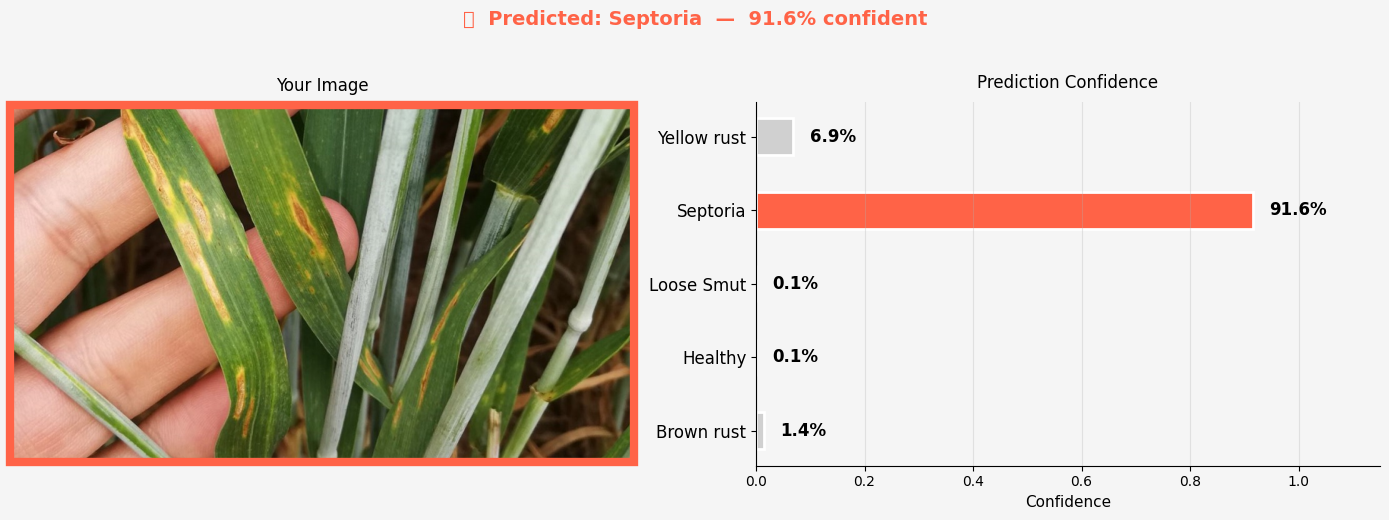


════════════════════════════════════════════════════
  🔴  Predicted  : Septoria
  Confidence   : 91.57%
  Description  : Septoria — brown blotches caused by Zymoseptoria tritici.
────────────────────────────────────────────────────
  Brown rust     ░░░░░░░░░░░░░░░░░░░░░░░░░  1.39%
  Healthy        ░░░░░░░░░░░░░░░░░░░░░░░░░  0.07%
  Loose Smut     ░░░░░░░░░░░░░░░░░░░░░░░░░  0.08%
  Septoria       ██████████████████████░░░  91.57% ← predicted
  Yellow rust    █░░░░░░░░░░░░░░░░░░░░░░░░  6.89%
════════════════════════════════════════════════════


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import warnings
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ══════════════════════════════════════════════════════════
#  ✏️  SET YOUR IMAGE PATH HERE (copy from cell above)
# ══════════════════════════════════════════════════════════
IMAGE_PATH = '/kaggle/input/datasets/kritikag20/new-data/img1.jpg'
# ══════════════════════════════════════════════════════════


CLASSES = sorted(os.listdir(data_dir))

# ── Rebuild model (same architecture as training) ─────────────────────────────
def rebuild_model(checkpoint_path, num_classes=5):
    m = models.efficientnet_b0(weights=None)
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_f, 256),
        nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, num_classes)
    )
    ckpt = torch.load(checkpoint_path, map_location=device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m.to(device)


# ── Preprocess ────────────────────────────────────────────────────────────────
def preprocess(img):
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    return tf(img).unsqueeze(0).to(device)


# ── Run ───────────────────────────────────────────────────────────────────────
print('Loading model...')
inf_model = rebuild_model('/kaggle/working/checkpoints/best_model.pth')

print(f'Loading image: {IMAGE_PATH}')
assert os.path.exists(IMAGE_PATH), f'❌ File not found: {IMAGE_PATH}\nCheck the path printed in the cell above.'
original_img = Image.open(IMAGE_PATH).convert('RGB')
print(f'Image size: {original_img.size}')

tensor     = preprocess(original_img)

with torch.no_grad():
    out   = inf_model(tensor)
    probs = F.softmax(out, dim=1).squeeze().cpu().numpy()

pred_idx   = probs.argmax()
pred_class = CLASSES[pred_idx]
confidence = probs[pred_idx]
emoji, color, description = CLASS_INFO[pred_class]


# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5), facecolor='#f5f5f5')

# Left — image
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(original_img)
ax1.axis('off')
ax1.set_title('Your Image', fontsize=12, pad=10)
rect = patches.FancyBboxPatch(
    (0, 0), 1, 1, transform=ax1.transAxes,
    boxstyle='square,pad=0', linewidth=6,
    edgecolor=color, facecolor='none', clip_on=False
)
ax1.add_patch(rect)

# Right — confidence bars
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_facecolor('#f5f5f5')
bar_colors = [CLASS_INFO[c][1] if c == pred_class else '#d0d0d0' for c in CLASSES]
bars = ax2.barh(np.arange(len(CLASSES)), probs, color=bar_colors, height=0.5,
                edgecolor='white', linewidth=2)
ax2.set_yticks(np.arange(len(CLASSES)))
ax2.set_yticklabels(CLASSES, fontsize=12)
ax2.set_xlim(0, 1.15)
ax2.set_xlabel('Confidence', fontsize=11)
ax2.set_title('Prediction Confidence', fontsize=12, pad=10)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
for bar, prob in zip(bars, probs):
    ax2.text(prob + 0.03, bar.get_y() + bar.get_height()/2,
             f'{prob:.1%}', va='center', fontsize=12, fontweight='bold')

plt.suptitle(
    f'{emoji}  Predicted: {pred_class}  —  {confidence:.1%} confident',
    fontsize=14, fontweight='bold', y=1.03, color=color
)
plt.tight_layout()
plt.savefig('/kaggle/working/my_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Print result ──────────────────────────────────────────────────────────────
print()
print('═' * 52)
print(f'  {emoji}  Predicted  : {pred_class}')
print(f'  Confidence   : {confidence:.2%}')
print(f'  Description  : {description}')
print('─' * 52)
for cls, prob in zip(CLASSES, probs):
    filled = '█' * int(prob * 25)
    empty  = '░' * (25 - int(prob * 25))
    marker = ' ← predicted' if cls == pred_class else ''
    print(f'  {cls:<14} {filled}{empty}  {prob:.2%}{marker}')
print('═' * 52)

In [34]:
# TTA on single image — run the same image 5 times with augmentation and average

tta_probs = np.zeros(len(CLASSES))
tta_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

for _ in range(5):
    t = tta_transform(original_img).unsqueeze(0).to(device)
    with torch.no_grad():
        p = F.softmax(inf_model(t), dim=1).squeeze().cpu().numpy()
    tta_probs += p

tta_probs /= 5
print(f"\nTTA Prediction: {CLASSES[tta_probs.argmax()]} ({tta_probs.max():.2%})")


TTA Prediction: Septoria (91.09%)
